# Thesis Evaluation Analysis — Financial RAG Pipeline

**Notebook Purpose:** Παράγει publication-quality figures για το κεφάλαιο Αξιολόγησης της διπλωματικής εργασίας.  
**Pipelines Evaluated:** `dense` · `hybrid` · `hybrid_reranked`  
**Benchmark:** FinanceBench (n=150 queries)  
**Frameworks:** Custom Retrieval Eval · RAGChecker · RAGAS

---
**Αναπαραγωγιμότητα:** Τρέξτε τα κελιά σειριακά. Τα figures αποθηκεύονται αυτόματα στον φάκελο `figures/`.

In [14]:
# =============================================================================
# CELL 1: Imports & Global Style Configuration
# =============================================================================
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec

warnings.filterwarnings('ignore')

# --- Output directory for figures ---
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# --- Publication-quality style ---
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
})

# --- Pipeline color palette ---
PALETTE = {
    'dense': '#4C72B0',           # Blue
    'hybrid': '#55A868',          # Green
    'hybrid_reranked': '#C44E52', # Red
}
LABELS = {
    'dense': 'Dense (Baseline)',
    'hybrid': 'Hybrid',
    'hybrid_reranked': 'Hybrid + Reranking',
}
PIPELINES = ['dense', 'hybrid', 'hybrid_reranked']

print('✅ Style configuration loaded.')
print(f'   Figures will be saved to: ./{FIG_DIR}/')

✅ Style configuration loaded.
   Figures will be saved to: ./figures/


In [15]:
# =============================================================================
# CELL 2: Data Loading
# =============================================================================

# --- Retrieval Evaluation ---
df_retrieval = pd.read_csv('../data/processed/evaluation/retrieval_evaluation_comparison.csv')

# --- QA Evaluation ---
df_qa = pd.read_csv('../data/processed/evaluation/qa_evaluation_comparison.csv')

# --- RAGChecker Summaries ---
def load_ragchecker_summary(path, run_name):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    df['run_name'] = run_name
    return df

rc_dense    = load_ragchecker_summary('../data/processed/evaluation/ragchecker_summary_dense.csv', 'dense')
rc_hybrid   = load_ragchecker_summary('../data/processed/evaluation/ragchecker_summary_hybrid.csv', 'hybrid')
rc_reranked = load_ragchecker_summary('../data/processed/evaluation/ragchecker_summary_reranked.csv', 'hybrid_reranked')
df_rc = pd.concat([rc_dense, rc_hybrid, rc_reranked], ignore_index=True)

# Pivot to wide format
df_rc_wide = df_rc.pivot_table(
    index='run_name', columns='metric_name', values='metric_value'
).reset_index()

# --- RAGAS ---
df_ragas = pd.read_csv('../data/processed/evaluation/ragas_results.csv')

# --- RAGChecker Details (per-query) ---
def load_rc_details(path, run_name):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip().str.lstrip('\ufeff')
    df['run_name'] = run_name
    return df

rc_det_dense    = load_rc_details('../data/processed/evaluation/ragchecker_details_dense.csv', 'dense')
rc_det_hybrid   = load_rc_details('../data/processed/evaluation/ragchecker_details_hybrid.csv', 'hybrid')
rc_det_reranked = load_rc_details('../data/processed/evaluation/ragchecker_details_reranked.csv', 'hybrid_reranked')
df_rc_details   = pd.concat([rc_det_dense, rc_det_hybrid, rc_det_reranked], ignore_index=True)

# --- FinanceBench Master ---
df_master = pd.read_csv('../data/processed/evaluation/financebench_master_results.csv')

print('✅ All datasets loaded.')
print(f'   Retrieval evaluation: {df_retrieval.shape}')
print(f'   QA evaluation: {df_qa.shape}')
print(f'   RAGChecker (all pipelines): {df_rc_details.shape}')
print(f'   RAGAS results: {df_ragas.shape}')
df_rc_wide

✅ All datasets loaded.
   Retrieval evaluation: (3, 8)
   QA evaluation: (3, 7)
   RAGChecker (all pipelines): (450, 17)
   RAGAS results: (3, 5)


metric_name,run_name,claim_recall,context_precision,context_utilization,f1,faithfulness,hallucination,noise_sensitivity_in_irrelevant,noise_sensitivity_in_relevant,precision,recall,self_knowledge
0,dense,31.1,42.0,27.9,19.0,37.7,38.5,4.4,13.3,29.0,28.0,9.1
1,hybrid,31.0,42.7,28.9,18.9,40.9,36.7,7.2,13.4,26.7,29.4,6.4
2,hybrid_reranked,35.9,48.7,31.5,25.7,46.3,31.2,6.4,13.8,34.6,34.8,8.6


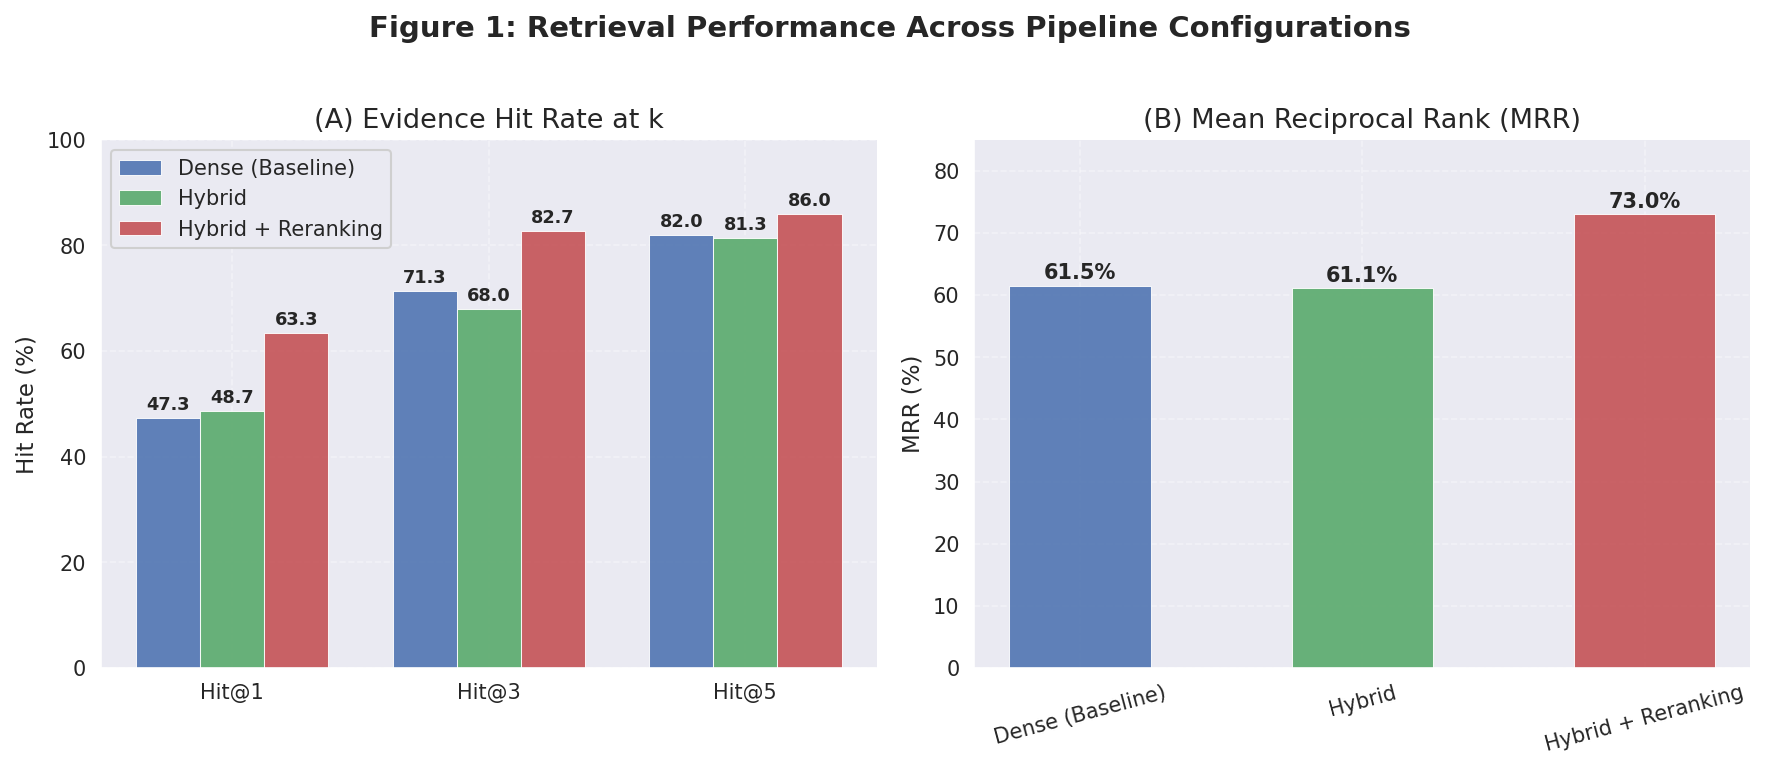

✅ Figure 1 saved.


In [16]:
# =============================================================================
# CELL 3: FIGURE 1 — Retrieval Performance (Hit@k & MRR)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1: Retrieval Performance Across Pipeline Configurations',
             fontsize=14, fontweight='bold', y=1.02)

# --- Panel A: Hit@k grouped bar chart ---
ax = axes[0]
metrics_hitk = ['evidence_hit_at_1', 'evidence_hit_at_3', 'evidence_hit_at_5']
labels_hitk  = ['Hit@1', 'Hit@3', 'Hit@5']

x = np.arange(len(metrics_hitk))
width = 0.25

for i, pipeline in enumerate(PIPELINES):
    row = df_retrieval[df_retrieval['run_name'] == pipeline].iloc[0]
    values = [row[m] * 100 for m in metrics_hitk]
    bars = ax.bar(x + i * width, values, width,
                  label=LABELS[pipeline], color=PALETTE[pipeline],
                  alpha=0.88, edgecolor='white', linewidth=0.5)
    # Value labels on bars
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(labels_hitk)
ax.set_ylabel('Hit Rate (%)')
ax.set_title('(A) Evidence Hit Rate at k')
ax.set_ylim(0, 100)
ax.legend(loc='upper left', framealpha=0.9)

# --- Panel B: MRR bar chart ---
ax2 = axes[1]
mrr_values = [df_retrieval[df_retrieval['run_name'] == p].iloc[0]['mrr'] * 100
              for p in PIPELINES]
bars = ax2.bar([LABELS[p] for p in PIPELINES], mrr_values,
               color=[PALETTE[p] for p in PIPELINES],
               alpha=0.88, edgecolor='white', linewidth=0.5, width=0.5)
for bar, val in zip(bars, mrr_values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_ylabel('MRR (%)')
ax2.set_title('(B) Mean Reciprocal Rank (MRR)')
ax2.set_ylim(0, 85)
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig1_retrieval_performance.png')
plt.show()
print('✅ Figure 1 saved.')

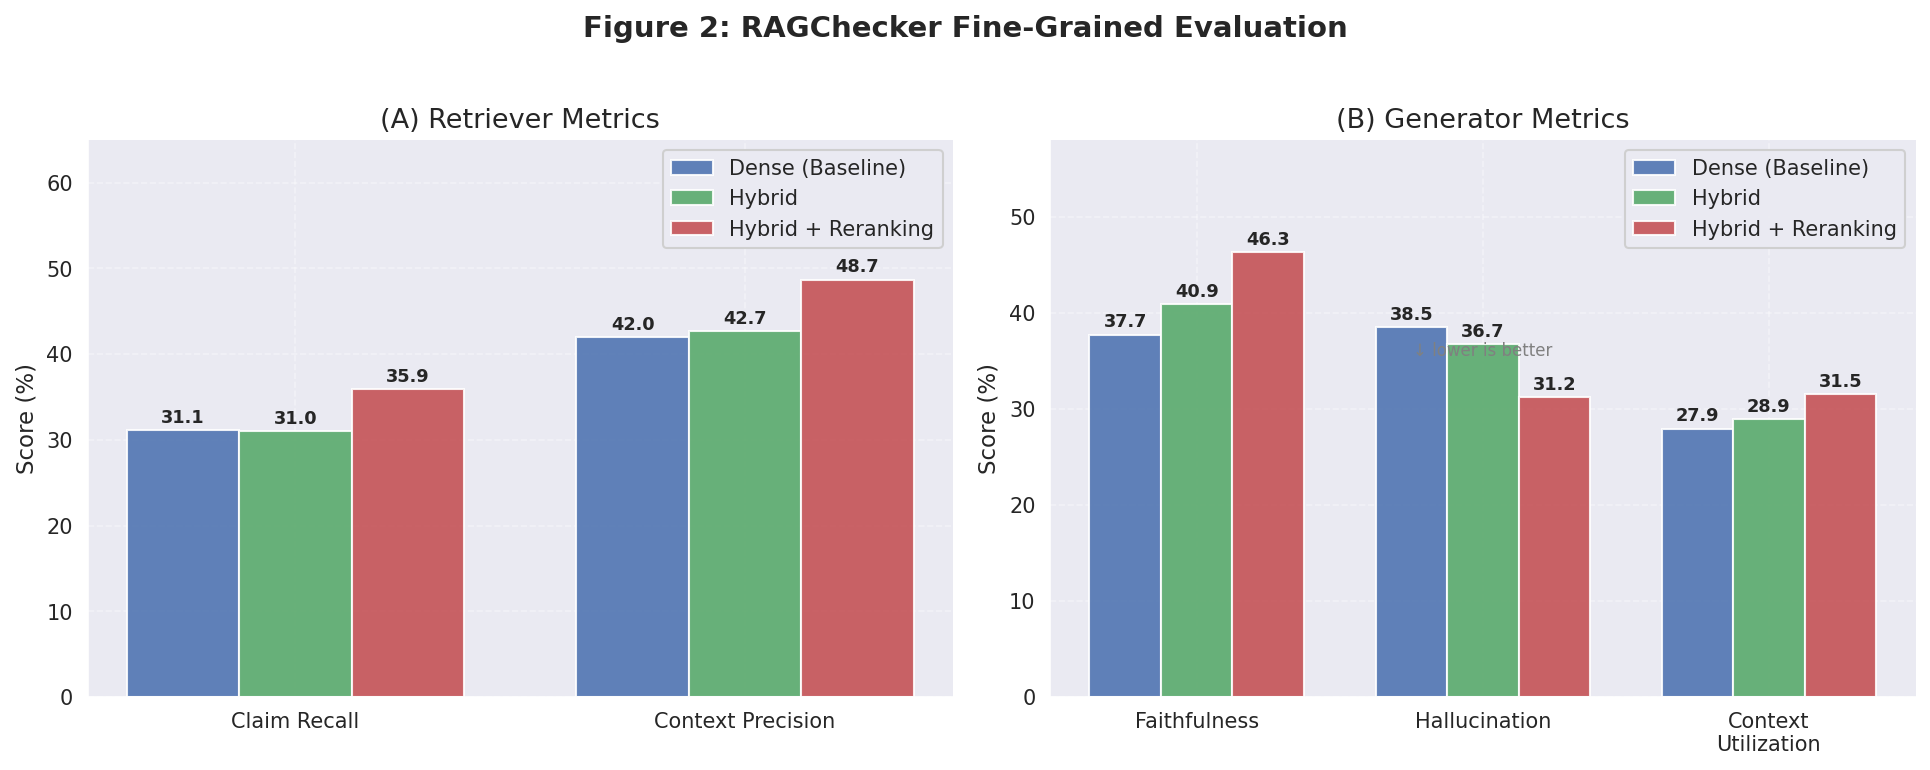

✅ Figure 2 saved.


In [17]:
# =============================================================================
# CELL 4: FIGURE 2 — RAGChecker: Retriever vs Generator Metrics
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2: RAGChecker Fine-Grained Evaluation',
             fontsize=14, fontweight='bold', y=1.02)

# --- Panel A: Retriever metrics ---
ax = axes[0]
retriever_metrics = ['claim_recall', 'context_precision']
ret_labels = ['Claim Recall', 'Context Precision']

x = np.arange(len(retriever_metrics))
width = 0.25

for i, pipeline in enumerate(PIPELINES):
    row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    values = [row[m] for m in retriever_metrics]
    bars = ax.bar(x + i * width, values, width,
                  label=LABELS[pipeline], color=PALETTE[pipeline],
                  alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(ret_labels)
ax.set_ylabel('Score (%)')
ax.set_title('(A) Retriever Metrics')
ax.set_ylim(0, 65)
ax.legend(framealpha=0.9)

# --- Panel B: Generator metrics ---
ax2 = axes[1]
gen_metrics = ['faithfulness', 'hallucination', 'context_utilization']
gen_labels  = ['Faithfulness', 'Hallucination', 'Context\nUtilization']

x2 = np.arange(len(gen_metrics))

for i, pipeline in enumerate(PIPELINES):
    row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    values = [row[m] for m in gen_metrics]
    bars = ax2.bar(x2 + i * width, values, width,
                   label=LABELS[pipeline], color=PALETTE[pipeline],
                   alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax2.set_xticks(x2 + width)
ax2.set_xticklabels(gen_labels)
ax2.set_ylabel('Score (%)')
ax2.set_title('(B) Generator Metrics')
ax2.set_ylim(0, 58)
ax2.legend(framealpha=0.9)

# Annotate: hallucination is inverted (lower = better)
ax2.annotate('↓ lower is better', xy=(1 + width, df_rc_wide[df_rc_wide['run_name']=='dense'].iloc[0]['hallucination'] - 3),
             fontsize=8, color='gray', ha='center')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig2_ragchecker_metrics.png')
plt.show()
print('✅ Figure 2 saved.')

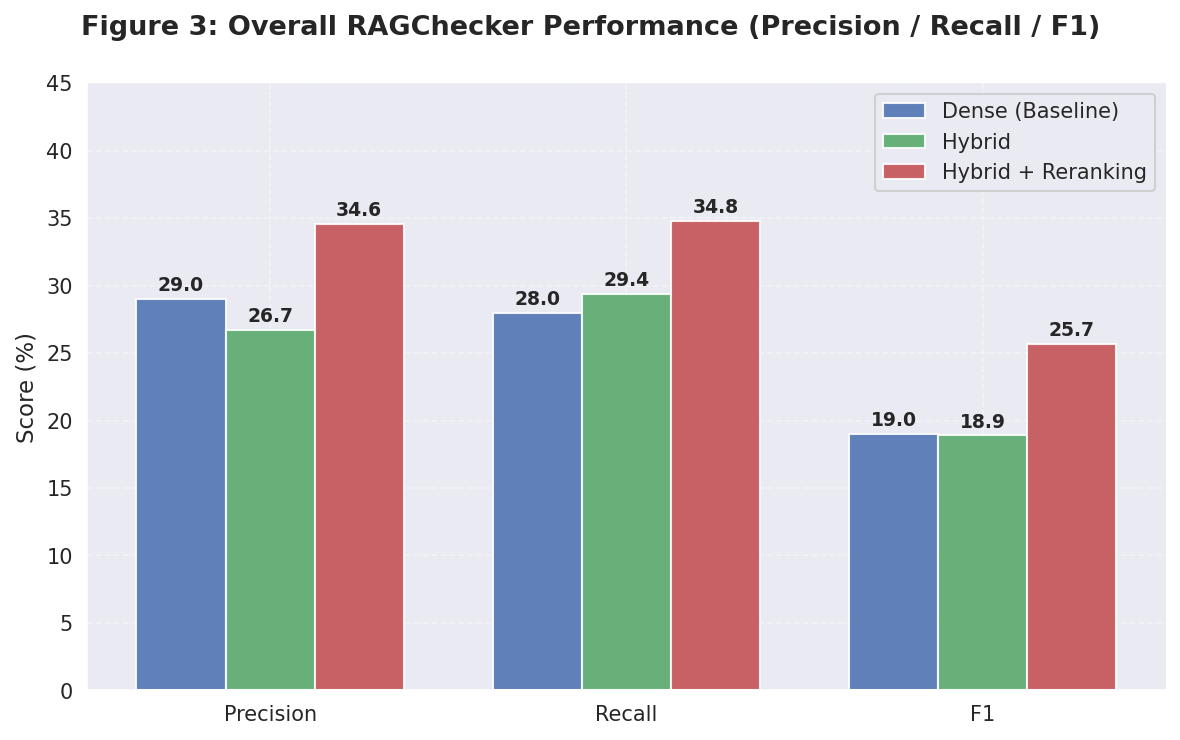

✅ Figure 3 saved.


In [18]:
# =============================================================================
# CELL 5: FIGURE 3 — Overall RAGChecker F1 / Precision / Recall
# =============================================================================

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('Figure 3: Overall RAGChecker Performance (Precision / Recall / F1)',
             fontsize=13, fontweight='bold')

overall_metrics = ['precision', 'recall', 'f1']
ov_labels = ['Precision', 'Recall', 'F1']
x = np.arange(len(overall_metrics))
width = 0.25

for i, pipeline in enumerate(PIPELINES):
    row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    values = [row[m] for m in overall_metrics]
    bars = ax.bar(x + i * width, values, width,
                  label=LABELS[pipeline], color=PALETTE[pipeline],
                  alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(ov_labels)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 45)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig3_ragchecker_overall.png')
plt.show()
print('✅ Figure 3 saved.')

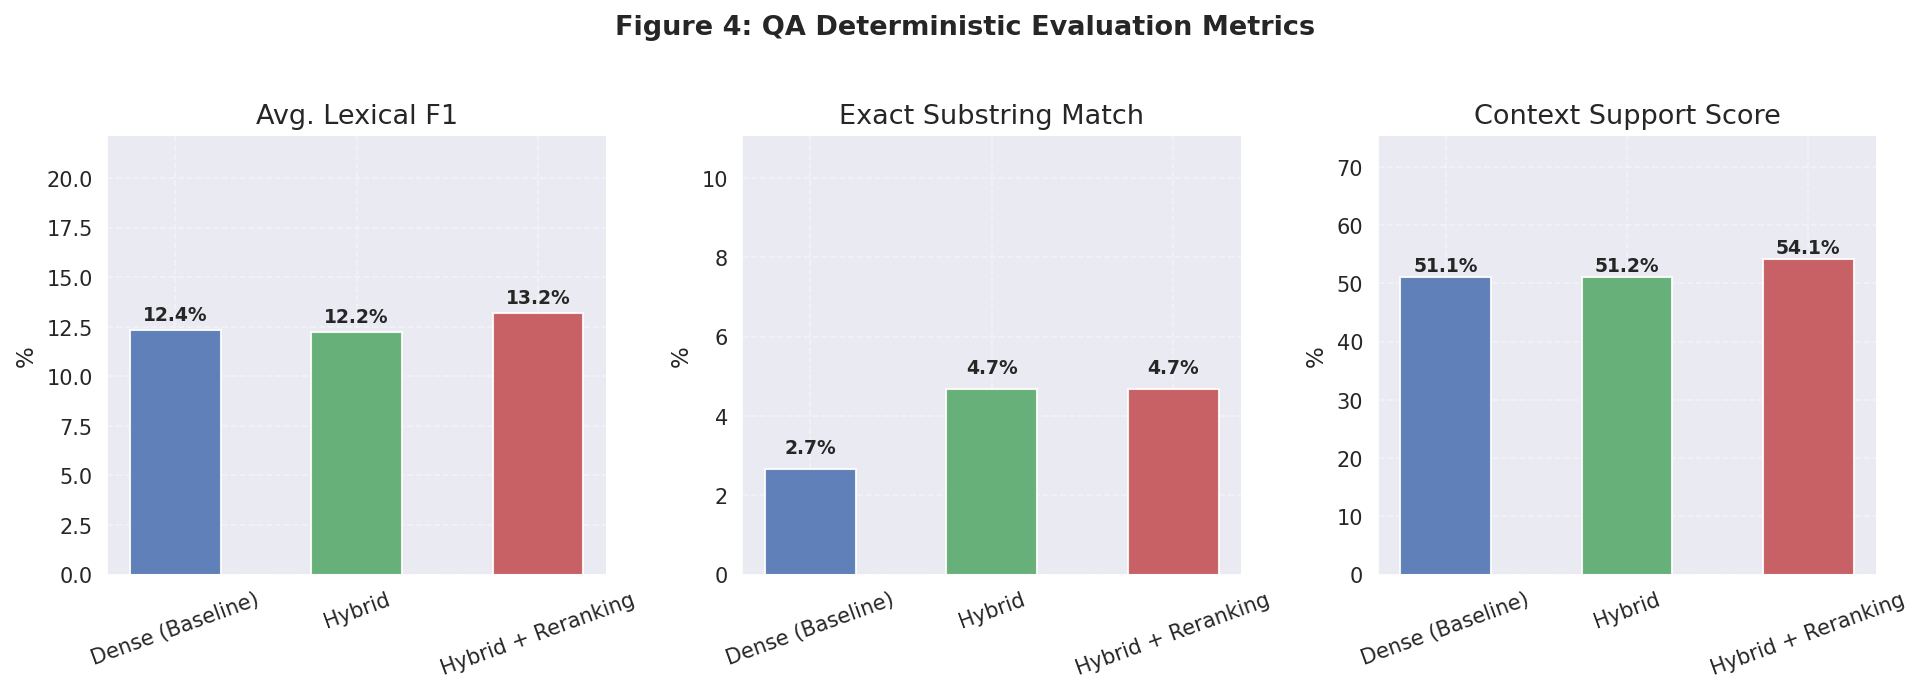

✅ Figure 4 saved.


In [19]:
# =============================================================================
# CELL 6: FIGURE 4 — QA Deterministic Metrics
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle('Figure 4: QA Deterministic Evaluation Metrics',
             fontsize=13, fontweight='bold', y=1.02)

qa_metrics  = ['avg_lexical_f1', 'exact_substring_match_rate', 'avg_context_support_score']
qa_mlabels  = ['Avg. Lexical F1', 'Exact Substring Match', 'Context Support Score']
qa_scale    = [100, 100, 100]   # convert 0-1 → percentage

for idx, (metric, label) in enumerate(zip(qa_metrics, qa_mlabels)):
    ax = axes[idx]
    values = [
        df_qa[df_qa['run_name'] == p].iloc[0][metric] * qa_scale[idx]
        for p in PIPELINES
    ]
    bars = ax.bar([LABELS[p] for p in PIPELINES], values,
                  color=[PALETTE[p] for p in PIPELINES],
                  alpha=0.88, edgecolor='white', width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(label)
    ax.set_ylabel('%')
    ax.set_ylim(0, max(values) * 1.3 + 5)
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig4_qa_deterministic.png')
plt.show()
print('✅ Figure 4 saved.')

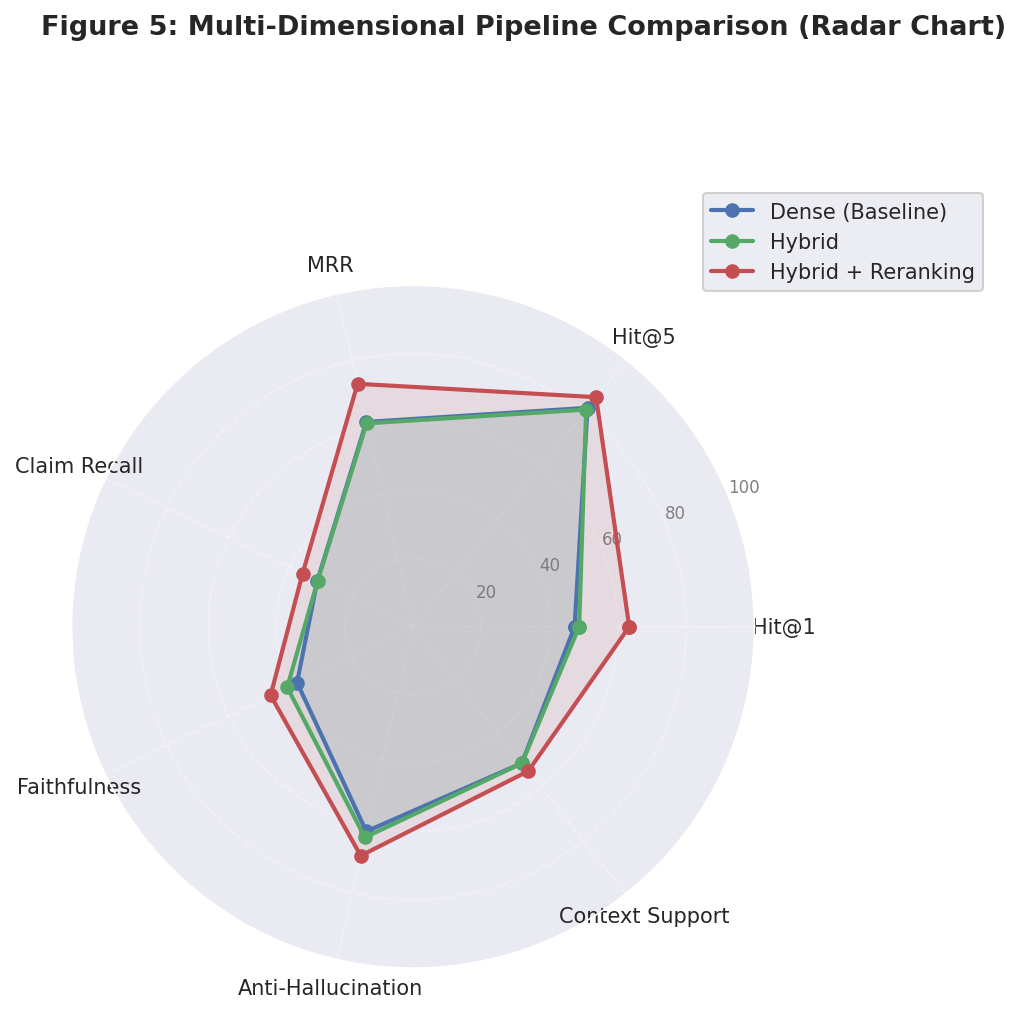

✅ Figure 5 saved.


In [20]:
# =============================================================================
# CELL 7: FIGURE 5 — Radar Chart (Spider Plot) — Full Pipeline Comparison
# =============================================================================

# Metrics selected for radar — all normalized to 0-100, higher=better
# Note: hallucination is INVERTED (lower hallucination = better)
radar_metrics = {
    'Hit@1'            : 'evidence_hit_at_1',
    'Hit@5'            : 'evidence_hit_at_5',
    'MRR'              : 'mrr',
    'Claim Recall'     : None,   # from RAGChecker
    'Faithfulness'     : None,
    'Anti-Hallucination': None,  # = 100 - hallucination
    'Context Support'  : None,   # from QA
}

# Build values dict
radar_data = {}
for pipeline in PIPELINES:
    r_row = df_retrieval[df_retrieval['run_name'] == pipeline].iloc[0]
    rc_row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    qa_row = df_qa[df_qa['run_name'] == pipeline].iloc[0]
    
    radar_data[pipeline] = [
        r_row['evidence_hit_at_1'] * 100,
        r_row['evidence_hit_at_5'] * 100,
        r_row['mrr'] * 100,
        rc_row['claim_recall'],
        rc_row['faithfulness'],
        100 - rc_row['hallucination'],   # inverted
        qa_row['avg_context_support_score'] * 100,
    ]

labels = list(radar_metrics.keys())
N = len(labels)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
fig.suptitle('Figure 5: Multi-Dimensional Pipeline Comparison (Radar Chart)',
             fontsize=13, fontweight='bold', y=1.02)

for pipeline in PIPELINES:
    values = radar_data[pipeline]
    values += values[:1]  # close
    ax.plot(angles, values, 'o-', linewidth=2,
            label=LABELS[pipeline], color=PALETTE[pipeline])
    ax.fill(angles, values, alpha=0.10, color=PALETTE[pipeline])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylim(0, 100)
ax.yaxis.set_tick_params(labelsize=8)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_yticklabels(['20', '40', '60', '80', '100'], color='gray', fontsize=8)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), framealpha=0.9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig5_radar_chart.png')
plt.show()
print('✅ Figure 5 saved.')

In [21]:
# =============================================================================
# CELL 8: FIGURE 6 — Per-Query Distribution (RAGChecker F1 boxplot)
# =============================================================================

# Check column names in details
print(df_rc_details.columns.tolist())
print(df_rc_details.head(2))

['query_id', 'query', 'gt_answer', 'response', 'n_context_chunks', 'metrics.claim_recall', 'metrics.context_precision', 'metrics.hallucination', 'metrics.self_knowledge', 'metrics.precision', 'metrics.recall', 'metrics.f1', 'metrics.noise_sensitivity_in_relevant', 'metrics.noise_sensitivity_in_irrelevant', 'metrics.faithfulness', 'metrics.context_utilization', 'run_name']
                query_id                                              query  \
0  financebench_id_03029  What is the FY2018 capital expenditure amount ...   
1  financebench_id_04672  Assume that you are a public equities analyst....   

  gt_answer                                           response  \
0  $1577.00  For 3M, the purchases of property, plant and e...   
1     $8.70  The year-end FY2018 net Property, Plant and Eq...   

   n_context_chunks  metrics.claim_recall  metrics.context_precision  \
0                 1                   1.0                        1.0   
1                 1                   1.0   

Metric columns: ['metrics.claim_recall', 'metrics.context_precision', 'metrics.hallucination', 'metrics.self_knowledge', 'metrics.precision', 'metrics.recall', 'metrics.f1', 'metrics.noise_sensitivity_in_relevant', 'metrics.noise_sensitivity_in_irrelevant', 'metrics.faithfulness', 'metrics.context_utilization']


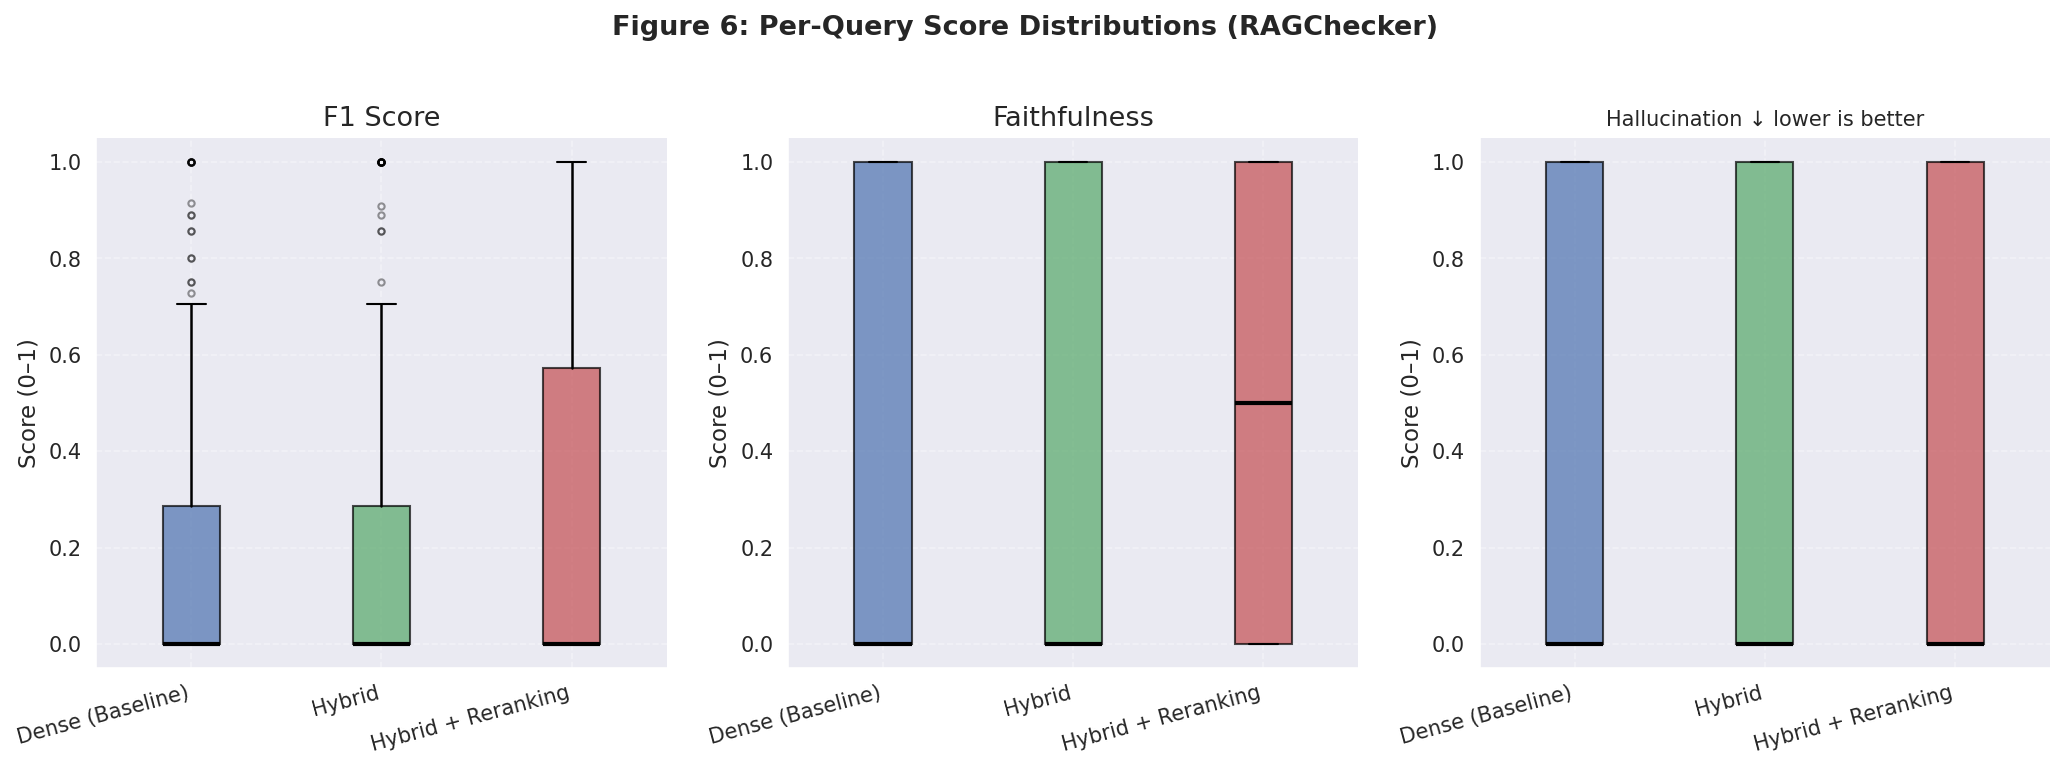

✅ Figure 6 saved.


In [22]:
# =============================================================================
# CELL 8b: FIGURE 6 — Per-Query Distribution (boxplot)
# =============================================================================

# Identify numeric per-query metric columns
metric_cols = [c for c in df_rc_details.columns
               if c.startswith('metrics.') and df_rc_details[c].dtype in [np.float64, float]]
print('Metric columns:', metric_cols)

# Focus: f1 per query per pipeline
f1_col = 'metrics.f1' if 'metrics.f1' in df_rc_details.columns else metric_cols[0]
faith_col = 'metrics.faithfulness' if 'metrics.faithfulness' in df_rc_details.columns else None
hall_col  = 'metrics.hallucination' if 'metrics.hallucination' in df_rc_details.columns else None

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Figure 6: Per-Query Score Distributions (RAGChecker)',
             fontsize=13, fontweight='bold', y=1.02)

for ax_idx, (col, title) in enumerate([
        (f1_col, 'F1 Score'),
        (faith_col, 'Faithfulness'),
        (hall_col, 'Hallucination')]):
    ax = axes[ax_idx]
    if col is None:
        ax.set_visible(False)
        continue
    data_groups = [
        df_rc_details[df_rc_details['run_name'] == p][col].dropna().values
        for p in PIPELINES
    ]
    bp = ax.boxplot(data_groups, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
    for patch, pipeline in zip(bp['boxes'], PIPELINES):
        patch.set_facecolor(PALETTE[pipeline])
        patch.set_alpha(0.7)
    
    ax.set_xticks(range(1, len(PIPELINES)+1))
    ax.set_xticklabels([LABELS[p] for p in PIPELINES], rotation=15, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Score (0–1)')
    ax.set_ylim(-0.05, 1.05)
    if col == hall_col:
        ax.set_title(f'{title} ↓ lower is better', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig6_per_query_distributions.png')
plt.show()
print('✅ Figure 6 saved.')

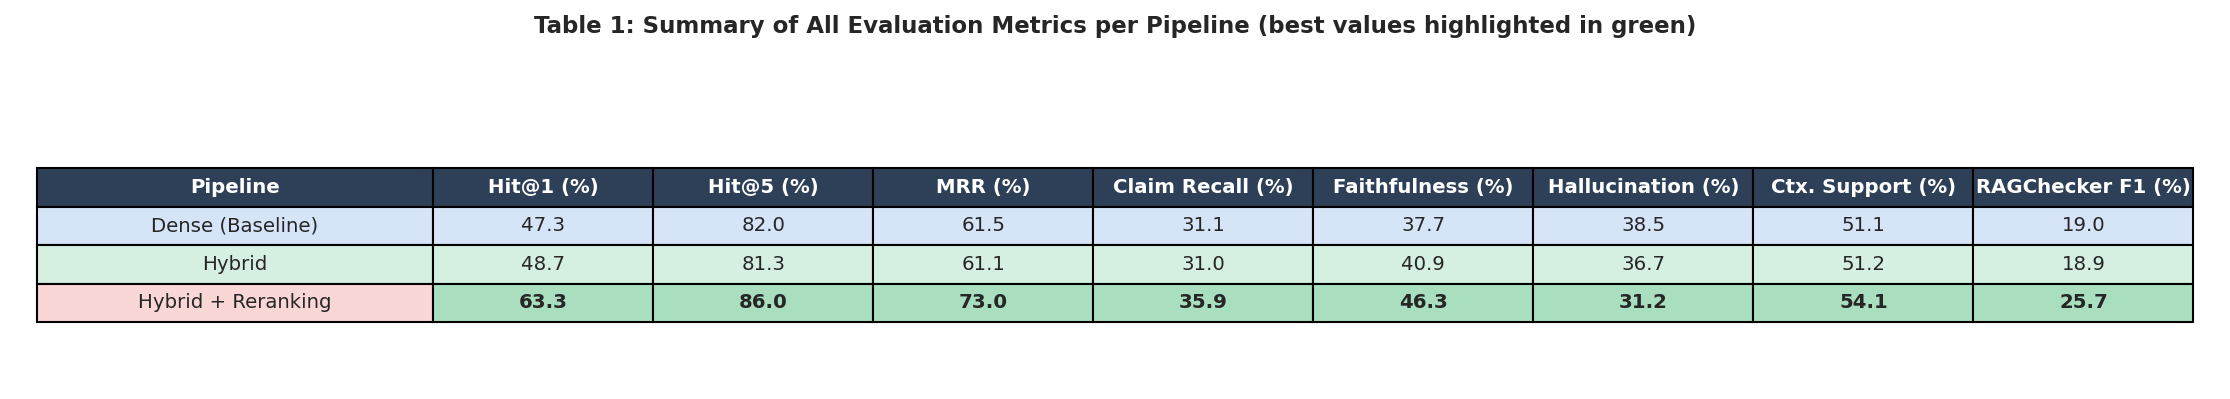

✅ Figure 7 (Summary Table) saved.


In [23]:
# =============================================================================
# CELL 9: FIGURE 7 — Summary Table (Publication-ready)
# =============================================================================

# Build summary table
rows = []
for pipeline in PIPELINES:
    r_row  = df_retrieval[df_retrieval['run_name'] == pipeline].iloc[0]
    rc_row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    qa_row = df_qa[df_qa['run_name'] == pipeline].iloc[0]
    rows.append({
        'Pipeline'          : LABELS[pipeline],
        'Hit@1 (%)'         : f"{r_row['evidence_hit_at_1']*100:.1f}",
        'Hit@5 (%)'         : f"{r_row['evidence_hit_at_5']*100:.1f}",
        'MRR (%)'           : f"{r_row['mrr']*100:.1f}",
        'Claim Recall (%)'  : f"{rc_row['claim_recall']:.1f}",
        'Faithfulness (%)'  : f"{rc_row['faithfulness']:.1f}",
        'Hallucination (%)'  : f"{rc_row['hallucination']:.1f}",
        'Ctx. Support (%)'  : f"{qa_row['avg_context_support_score']*100:.1f}",
        'RAGChecker F1 (%)' : f"{rc_row['f1']:.1f}",
    })

df_table = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(15, 2.5))
ax.axis('off')

col_widths = [0.18] + [0.10] * (len(df_table.columns) - 1)

tbl = ax.table(
    cellText=df_table.values,
    colLabels=df_table.columns,
    cellLoc='center',
    loc='center',
    colWidths=col_widths,
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1, 1.6)

# Style header
for j in range(len(df_table.columns)):
    tbl[(0, j)].set_facecolor('#2E4057')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')

# Style rows
row_colors = ['#EBF5FB', '#FDFEFE', '#FDFEFE']
pipeline_colors_light = ['#D6E4F7', '#D5F0E0', '#FAD7D7']
for i, pipeline in enumerate(PIPELINES):
    for j in range(len(df_table.columns)):
        tbl[(i+1, j)].set_facecolor(pipeline_colors_light[i])

# Highlight best values (manually — last row = reranked)
best_cols = [1, 2, 3, 4, 5, 7, 8]  # higher is better
for col_idx in best_cols:
    values = [float(tbl[(r+1, col_idx)].get_text().get_text()) for r in range(3)]
    best_row = np.argmax(values)
    tbl[(best_row+1, col_idx)].set_text_props(fontweight='bold')
    tbl[(best_row+1, col_idx)].set_facecolor('#A9DFBF')

# Hallucination: lower is better (col index 6)
hall_values = [float(tbl[(r+1, 6)].get_text().get_text()) for r in range(3)]
best_hall = np.argmin(hall_values)
tbl[(best_hall+1, 6)].set_text_props(fontweight='bold')
tbl[(best_hall+1, 6)].set_facecolor('#A9DFBF')

fig.suptitle('Table 1: Summary of All Evaluation Metrics per Pipeline (best values highlighted in green)',
             fontsize=11, fontweight='bold', y=1.05)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig7_summary_table.png')
plt.show()
print('✅ Figure 7 (Summary Table) saved.')

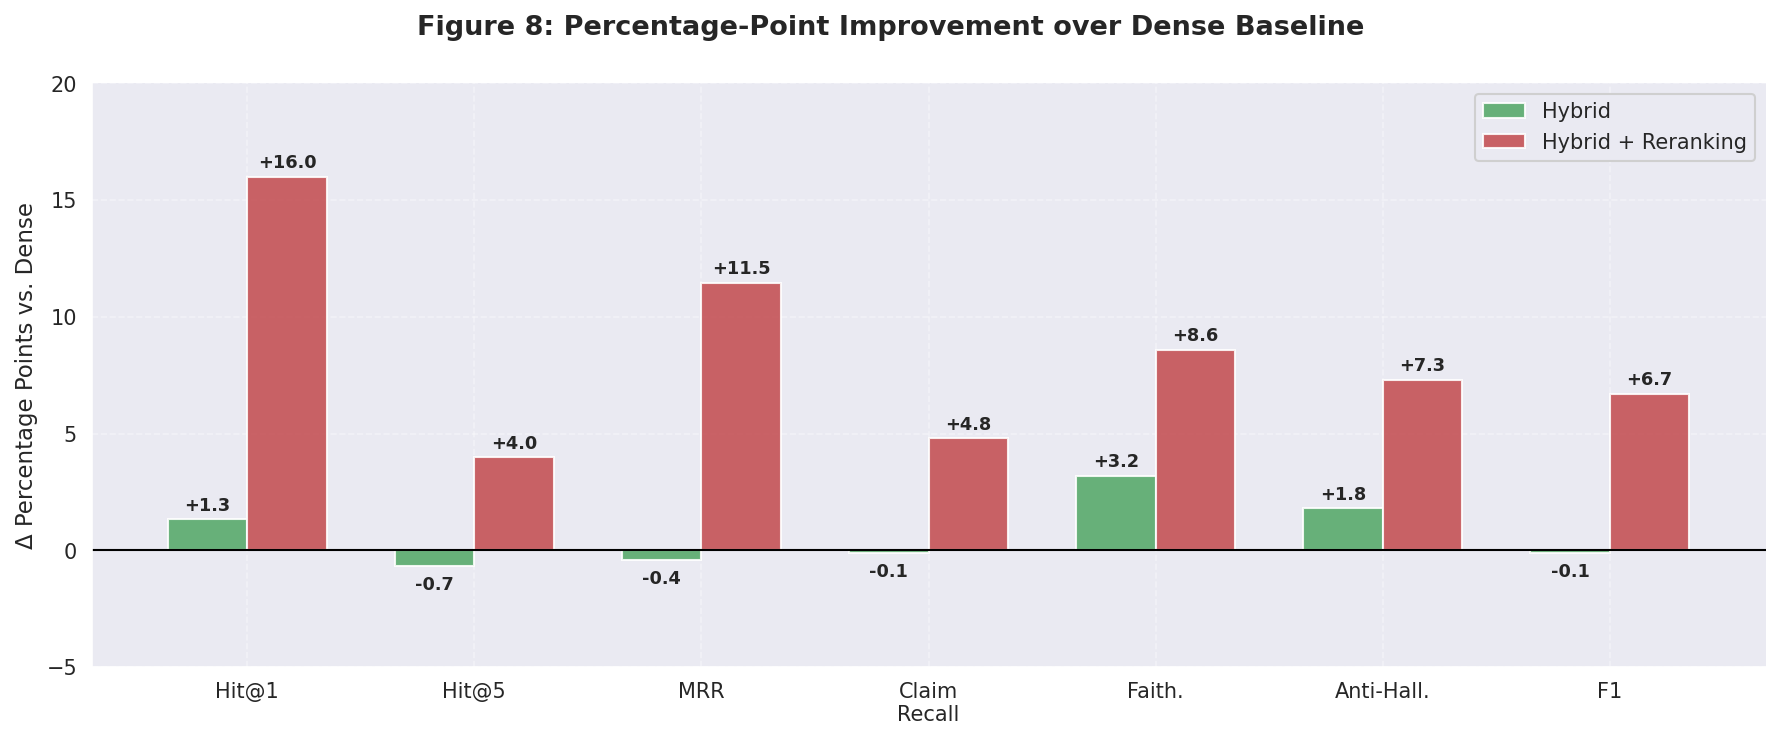

✅ Figure 8 saved.


In [24]:
# =============================================================================
# CELL 10: FIGURE 8 — Delta / Improvement Analysis (vs. Dense Baseline)
# =============================================================================

# Δ values relative to dense baseline
baseline = {
    'Hit@1': df_retrieval[df_retrieval['run_name']=='dense'].iloc[0]['evidence_hit_at_1']*100,
    'Hit@5': df_retrieval[df_retrieval['run_name']=='dense'].iloc[0]['evidence_hit_at_5']*100,
    'MRR'  : df_retrieval[df_retrieval['run_name']=='dense'].iloc[0]['mrr']*100,
    'Claim\nRecall': df_rc_wide[df_rc_wide['run_name']=='dense'].iloc[0]['claim_recall'],
    'Faith.': df_rc_wide[df_rc_wide['run_name']=='dense'].iloc[0]['faithfulness'],
    'Anti-Hall.': 100 - df_rc_wide[df_rc_wide['run_name']=='dense'].iloc[0]['hallucination'],
    'F1'   : df_rc_wide[df_rc_wide['run_name']=='dense'].iloc[0]['f1'],
}

def get_vals(pipeline):
    r  = df_retrieval[df_retrieval['run_name']==pipeline].iloc[0]
    rc = df_rc_wide[df_rc_wide['run_name']==pipeline].iloc[0]
    return {
        'Hit@1': r['evidence_hit_at_1']*100,
        'Hit@5': r['evidence_hit_at_5']*100,
        'MRR'  : r['mrr']*100,
        'Claim\nRecall': rc['claim_recall'],
        'Faith.': rc['faithfulness'],
        'Anti-Hall.': 100 - rc['hallucination'],
        'F1'   : rc['f1'],
    }

metric_keys = list(baseline.keys())
x = np.arange(len(metric_keys))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 8: Percentage-Point Improvement over Dense Baseline',
             fontsize=13, fontweight='bold')

for offset, pipeline in zip([-width/2, width/2], ['hybrid', 'hybrid_reranked']):
    vals = get_vals(pipeline)
    deltas = [vals[k] - baseline[k] for k in metric_keys]
    bars = ax.bar(x + offset, deltas, width,
                  label=LABELS[pipeline], color=PALETTE[pipeline],
                  alpha=0.88, edgecolor='white')
    for bar, d in zip(bars, deltas):
        sign = '+' if d >= 0 else ''
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.2 if d >= 0 else -1.2),
                f'{sign}{d:.1f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.axhline(0, color='black', linewidth=1, linestyle='-')
ax.set_xticks(x)
ax.set_xticklabels(metric_keys)
ax.set_ylabel('Δ Percentage Points vs. Dense')
ax.legend(framealpha=0.9)
ax.set_ylim(-5, 20)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig8_delta_improvement.png')
plt.show()
print('✅ Figure 8 saved.')

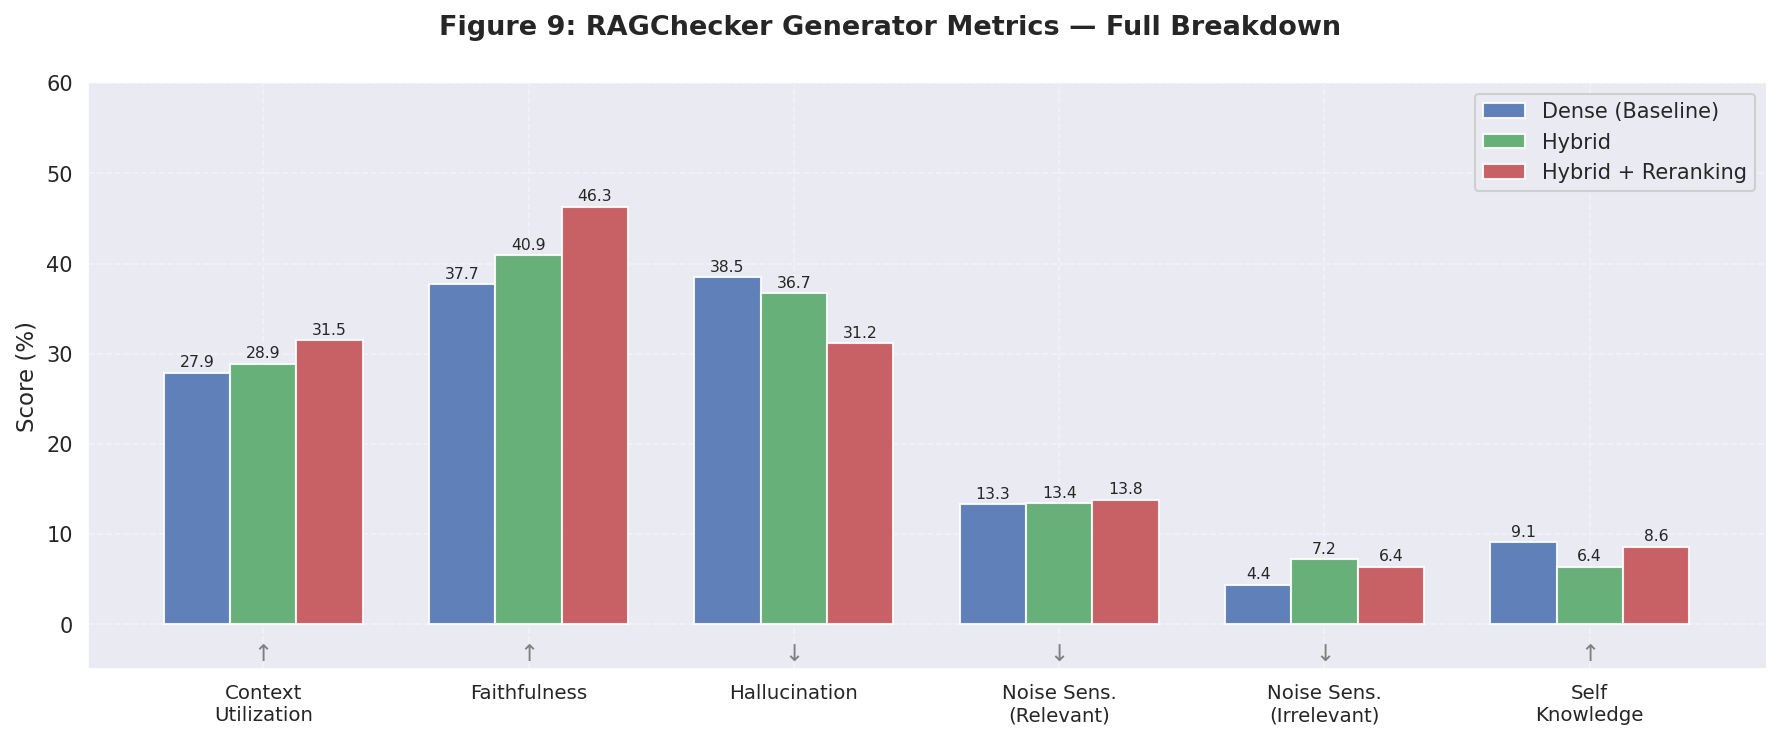

✅ Figure 9 saved.


In [25]:
# =============================================================================
# CELL 11: FIGURE 9 — RAGChecker Generator Deep-Dive
#          (Noise Sensitivity & Self-Knowledge)
# =============================================================================

gen_full = ['context_utilization', 'faithfulness', 'hallucination',
            'noise_sensitivity_in_relevant', 'noise_sensitivity_in_irrelevant', 'self_knowledge']
gen_full_labels = ['Context\nUtilization', 'Faithfulness', 'Hallucination',
                   'Noise Sens.\n(Relevant)', 'Noise Sens.\n(Irrelevant)', 'Self\nKnowledge']

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Figure 9: RAGChecker Generator Metrics — Full Breakdown',
             fontsize=13, fontweight='bold')

x = np.arange(len(gen_full))
width = 0.25

for i, pipeline in enumerate(PIPELINES):
    row = df_rc_wide[df_rc_wide['run_name'] == pipeline].iloc[0]
    values = [row[m] for m in gen_full]
    bars = ax.bar(x + i * width, values, width,
                  label=LABELS[pipeline], color=PALETTE[pipeline],
                  alpha=0.88, edgecolor='white')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(gen_full_labels, fontsize=9.5)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 58)
ax.legend(framealpha=0.9)

# Annotate: which direction is better for each metric
for idx, m in enumerate(gen_full):
    direction = '↓' if m in ['hallucination', 'noise_sensitivity_in_relevant', 'noise_sensitivity_in_irrelevant'] else '↑'
    ax.text(idx + width, -4, direction, ha='center', fontsize=11, color='gray')

ax.set_ylim(-5, 60)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/fig9_generator_deep_dive.png')
plt.show()
print('✅ Figure 9 saved.')

In [26]:
# =============================================================================
# CELL 12: Summary — All figures produced
# =============================================================================

import os
figures = sorted([f for f in os.listdir(FIG_DIR) if f.endswith('.png')])
print(f'\n✅ Notebook complete. {len(figures)} figures saved to ./{FIG_DIR}/')
print('\nFigure index for thesis:')
descriptions = {
    'fig1_retrieval_performance.png' : 'Figure 1  — Hit@k & MRR per pipeline',
    'fig2_ragchecker_metrics.png'    : 'Figure 2  — RAGChecker Retriever & Generator metrics',
    'fig3_ragchecker_overall.png'    : 'Figure 3  — RAGChecker Overall F1/Precision/Recall',
    'fig4_qa_deterministic.png'      : 'Figure 4  — QA Deterministic metrics',
    'fig5_radar_chart.png'           : 'Figure 5  — Radar chart (multi-dimensional comparison)',
    'fig6_per_query_distributions.png': 'Figure 6 — Per-query score distributions (boxplots)',
    'fig7_summary_table.png'         : 'Table 1   — Master summary table (all metrics)',
    'fig8_delta_improvement.png'     : 'Figure 8  — Δ improvement vs. dense baseline',
    'fig9_generator_deep_dive.png'   : 'Figure 9  — Generator full breakdown',
}
for f in figures:
    print(f'  • {descriptions.get(f, f)}')


✅ Notebook complete. 9 figures saved to ./figures/

Figure index for thesis:
  • Figure 1  — Hit@k & MRR per pipeline
  • Figure 2  — RAGChecker Retriever & Generator metrics
  • Figure 3  — RAGChecker Overall F1/Precision/Recall
  • Figure 4  — QA Deterministic metrics
  • Figure 5  — Radar chart (multi-dimensional comparison)
  • Figure 6 — Per-query score distributions (boxplots)
  • Table 1   — Master summary table (all metrics)
  • Figure 8  — Δ improvement vs. dense baseline
  • Figure 9  — Generator full breakdown
